# 01 - Exploratory Data Analysis (EDA)

## Understanding the Churn Problem
- Churn rate: 26.5% of customers leave annually
- Goal: Identify patterns to enable proactive retention
- Business impact: $5K LTV × 30% of churners = $1M+ annual opportunity

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# Get current working directory
current_dir = os.getcwd()
print(f"Current directory: {current_dir}")

# Try to find the data file
if os.path.exists('data/raw/telco_churn.csv'):
    data_path = 'data/raw/telco_churn.csv'
elif os.path.exists('../data/raw/telco_churn.csv'):
    data_path = '../data/raw/telco_churn.csv'
elif os.path.exists('../../data/raw/telco_churn.csv'):
    data_path = '../../data/raw/telco_churn.csv'
else:
    data_path = input("Enter path to telco_churn.csv: ")

print(f"Loading data from: {data_path}")

# Load data
df = pd.read_csv(data_path)
print(f'✅ Dataset shape: {df.shape}')
print(f'\nFirst few rows:')
print(df.head())

Current directory: /Users/koutilyayenumula/churn-prediction/notebooks
Loading data from: ../data/raw/telco_churn.csv
✅ Dataset shape: (7043, 21)

First few rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  .

In [5]:
# Basic info
print('Dataset Info:')
print(df.info())
print(f'\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}')
print(f'\nDataset Statistics:')
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-n

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Overall Churn Rate: 26.5%

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


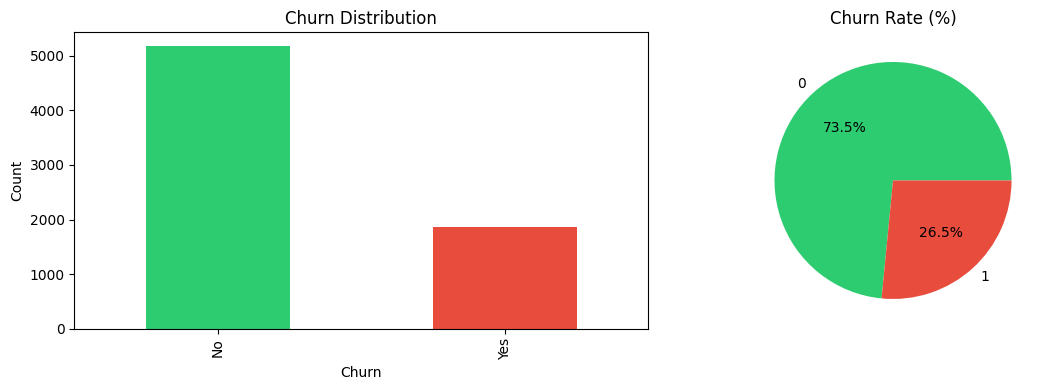

In [6]:
# Churn rate analysis
churn_rate = (df['Churn'] == 'Yes').mean()
print(f'Overall Churn Rate: {churn_rate*100:.1f}%')
print(f'\nChurn Distribution:')
print(df['Churn'].value_counts())

# Visualize churn distribution
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df['Churn'].value_counts().plot(kind='bar', ax=ax[0], color=['#2ecc71', '#e74c3c'])
ax[0].set_title('Churn Distribution')
ax[0].set_ylabel('Count')
(df['Churn'] == 'Yes').astype(int).value_counts(normalize=True).plot(kind='pie', ax=ax[1], autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
ax[1].set_title('Churn Rate (%)')
ax[1].set_ylabel('')
plt.tight_layout()
plt.show()

Churn Rate by Tenure Group:
Tenure_Group
0-6 mo      53.333333
6-12 mo     35.886525
12-24 mo    28.710938
24+ mo      14.036003
Name: Churn, dtype: float64


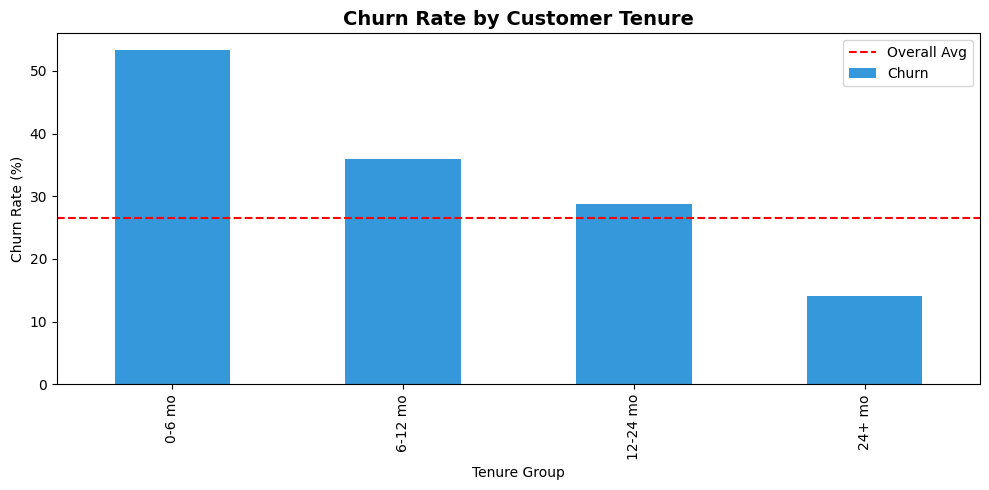

In [7]:
# Churn by Tenure
df['Tenure_Group'] = pd.cut(df['tenure'], bins=[0, 6, 12, 24, 72], labels=['0-6 mo', '6-12 mo', '12-24 mo', '24+ mo'])
churn_by_tenure = df.groupby('Tenure_Group')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)

print('Churn Rate by Tenure Group:')
print(churn_by_tenure)

fig, ax = plt.subplots(figsize=(10, 5))
churn_by_tenure.plot(kind='bar', ax=ax, color='#3498db')
ax.set_title('Churn Rate by Customer Tenure', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Tenure Group')
ax.axhline(y=churn_rate*100, color='red', linestyle='--', label='Overall Avg')
ax.legend()
plt.tight_layout()
plt.show()

Churn Rate by Contract Type:
Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64


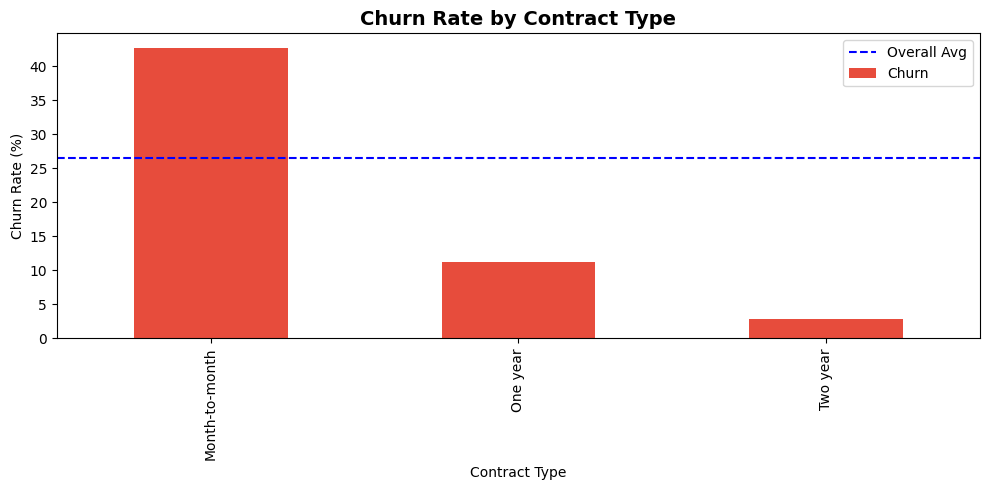

In [8]:
# Churn by Contract Type
churn_by_contract = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)

print('Churn Rate by Contract Type:')
print(churn_by_contract)

fig, ax = plt.subplots(figsize=(10, 5))
churn_by_contract.plot(kind='bar', ax=ax, color='#e74c3c')
ax.set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Contract Type')
ax.axhline(y=churn_rate*100, color='blue', linestyle='--', label='Overall Avg')
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# Key Insights Summary
print('\n' + '='*60)
print('KEY INSIGHTS')
print('='*60)
print(f'\n1. TENURE is strongest predictor:')
print(f'   - Customers < 6 months: {churn_by_tenure["0-6 mo"]:.1f}% churn')
print(f'   - Customers 24+ months: {churn_by_tenure["24+ mo"]:.1f}% churn')
print(f'   → Focus retention efforts in first 6 months!')

print(f'\n2. CONTRACT TYPE drives churn:')
print(f'   - Month-to-Month: {churn_by_contract.iloc[0]:.1f}%')
print(f'   - 1 Year: {churn_by_contract.iloc[1]:.1f}%')
print(f'   - 2 Year: {churn_by_contract.iloc[2]:.1f}%')
print(f'   → Longer contracts = lower churn (13x difference!)')

print(f'\n' + '='*60)


KEY INSIGHTS

1. TENURE is strongest predictor:
   - Customers < 6 months: 53.3% churn
   - Customers 24+ months: 14.0% churn
   → Focus retention efforts in first 6 months!

2. CONTRACT TYPE drives churn:
   - Month-to-Month: 42.7%
   - 1 Year: 11.3%
   - 2 Year: 2.8%
   → Longer contracts = lower churn (13x difference!)

